In [14]:
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [15]:
path = "./Dataset"
images = [] #list gambar
class_list = [] #list katgori gambar
label_class = ["Broccoli", "Carrot", "Cucumber", "Tomato"] #jenis kategori

In [16]:
def preprocess_image(path, size=(200, 200)):
    img = load_img(path, target_size=size)
    return tf.image.rgb_to_grayscale(img_to_array(img)) / 255.0


In [17]:
for i, label in enumerate(label_class):
    for img_name in os.listdir(os.path.join(path, label))[:501]:
        images.append(preprocess_image(os.path.join(path, label, img_name)))
        class_list.append(i)


In [18]:
y = tf.keras.utils.to_categorical(class_list, num_classes=len(label_class))
y
x = np.asarray(images)

In [19]:
#70 : 15 : 15
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [20]:
#conv : pool : covs : pool : flatten
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, kernel_size = (3, 3), strides = (1, 1), padding = "same", activation = "relu", input_shape = (200, 200, 1)),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Conv2D(16, kernel_size = (3, 3), strides = (1, 1), padding = "same", activation = "relu"),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(len(label_class), activation="softmax") #jumlah perception ngikutin jumlah label, activation pake softmax
])

In [21]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 200, 200, 16)      160       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 100, 100, 16)     0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 100, 100, 16)      2320      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 50, 50, 16)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 40000)             0         
                                                                 
 dense_3 (Dense)             (None, 32)               

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience = 3)

In [23]:
history = model.fit(x_train, y_train, validation_data = (x_val, y_val), epochs = 50, callbacks = early_stopping)

Epoch 1/50
44/44 [==============================] - 17s 360ms/step - loss: 1.3648 - accuracy: 0.3129 - val_loss: 1.1798 - val_accuracy: 0.4867
Epoch 2/50
44/44 [==============================] - 17s 395ms/step - loss: 0.9281 - accuracy: 0.6479 - val_loss: 0.8101 - val_accuracy: 0.6267
Epoch 3/50
44/44 [==============================] - 18s 401ms/step - loss: 0.6019 - accuracy: 0.7793 - val_loss: 0.5044 - val_accuracy: 0.8500
Epoch 4/50
44/44 [==============================] - 20s 453ms/step - loss: 0.4221 - accuracy: 0.8421 - val_loss: 0.4025 - val_accuracy: 0.8600
Epoch 5/50
44/44 [==============================] - 19s 425ms/step - loss: 0.3278 - accuracy: 0.8857 - val_loss: 0.3722 - val_accuracy: 0.8533
Epoch 6/50
44/44 [==============================] - 19s 422ms/step - loss: 0.2837 - accuracy: 0.9000 - val_loss: 0.3438 - val_accuracy: 0.8900
Epoch 7/50
44/44 [==============================] - 17s 388ms/step - loss: 0.2181 - accuracy: 0.9221 - val_loss: 0.3271 - val_accuracy: 0.8900

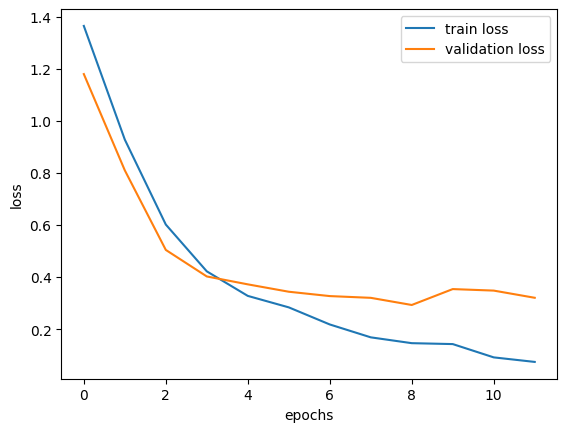

In [24]:
plt.plot(history.history["loss"], label = "train loss")
plt.plot(history.history["val_loss"], label = "validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

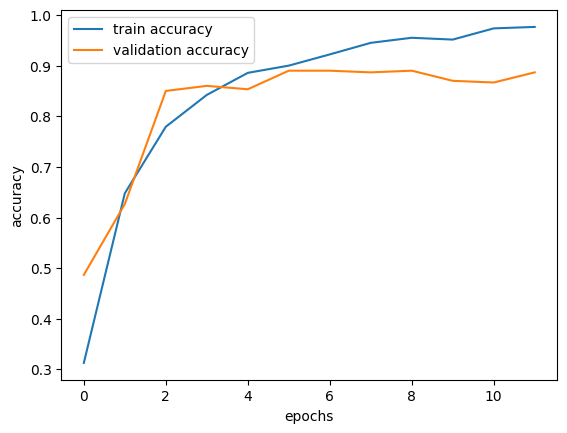

In [25]:
plt.plot(history.history["accuracy"], label = "train accuracy")
plt.plot(history.history["val_accuracy"], label = "validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [26]:
loss, arc = model.evaluate(x_test, y_test)

10/10 [==============================] - 1s 118ms/step - loss: 0.4363 - accuracy: 0.8600
